In [5657]:
import os
import pandas as pd
from dotenv import load_dotenv
import psycopg2

load_dotenv()

conn = psycopg2.connect(
    dbname="job_market",
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    # host="localhost",
    # port="5432"
)

In [5658]:
# test = pd.read_sql("SELECT COUNT(id) FROM jobs WHERE company = 'Hays Technology' GROUP BY company;", conn)
test = pd.read_sql("SELECT company, title, salary_min, salary_max, salary_is_predicted FROM jobs WHERE company = 'Harnham - Data & Analytics Recruitment';", conn)
test

/var/folders/tk/714_gq2n07975w41h5c2jqm40000gn/T/ipykernel_938/2562800257.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test = pd.read_sql("SELECT company, title, salary_min, salary_max, salary_is_predicted FROM jobs WHERE company = 'Harnham - Data & Analytics Recruitment';", conn)


,company,title,salary_min,salary_max,salary_is_predicted
0,Harnham - Data & Analytics Recruitment,Data Scientist,51182.60,51182.60,True
1,Harnham - Data & Analytics Recruitment,Data Scientist,54247.38,54247.38,True
2,Harnham - Data & Analytics Recruitment,Data Scientist,500.00,650.00,False
3,Harnham - Data & Analytics Recruitment,Data Scientist,75100.50,75100.50,True
4,Harnham - Data & Analytics Recruitment,Data Scientist,64392.47,64392.47,True
5,Harnham - Data & Analytics Recruitment,Data Scientist,65823.06,65823.06,True
6,Harnham - Data & Analytics Recruitment,Senior Data Scientist,60000.00,75000.00,False
7,Harnham - Data & Analytics Recruitment,Senior Data Scientist,65000.00,75000.00,False
8,Harnham - Data & Analytics Recruitment,Senior Data Scientist,65000.00,75000.00,False
9,Harnham - Data & Analytics Recruitment,Senior Data Scientist,45172.54,45172.54,True


In [5659]:
df = pd.read_sql("SELECT * FROM jobs;", conn)
df.to_csv("/Users/macbookair/Desktop/jobs.csv")
df.head(5)

/var/folders/tk/714_gq2n07975w41h5c2jqm40000gn/T/ipykernel_938/3280996743.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM jobs;", conn)


,id,adzuna_id,title,company,location,category,salary_min,salary_max,salary_is_predicted,contract_time,contract_type,description,created,fetched_at,search_term
0,2610,5852097024,Data Scientist,Hackajob Ltd,"Frimley, Camberley",IT Jobs,90000.00,90000.00,False,None,permanent,hackajob is partnering directly with BAE Syste...,2026-08-22 06:38:34,2026-09-01 07:27:05.292482,data scientist
1,2611,5861182268,Data Scientist,Ntt Data,"London, UK",IT Jobs,61153.77,61153.77,True,full_time,None,We are looking for a Data Scientist with at le...,2026-08-29 16:29:26,2026-09-01 07:27:05.292482,data scientist
2,2612,5825674473,Data Scientist / Senior Data Scientist,C3 AI,"London, UK",IT Jobs,59484.39,59484.39,True,full_time,None,"As a member of the C3 AI Data Science team, yo...",2026-08-02 14:00:14,2026-09-01 07:27:05.292482,data scientist
3,2613,5818233809,Lead Data Scientist,Hackajob Ltd,"Holbeck, Leeds",IT Jobs,100000.00,100000.00,False,None,permanent,hackajob is partnering directly with Jet2.com ...,2026-07-28 12:08:12,2026-09-01 07:27:05.292482,data scientist
4,2614,5856135789,Senior Data Scientist,TALENT INTERNATIONAL UK LTD,UK,IT Jobs,130000.00,152100.00,False,None,contract,Job Description: Role: Senior Data Scientist R...,2026-08-26 02:45:40,2026-09-01 07:27:05.292482,data scientist


## Data Cleaning and Exploratory Data Analysis

### Data Quality Note

The Adzuna API includes a `company.average_salary` field in its schema, but in practice 
this field was almost always null across our dataset of 1227 jobs. We initially included 
this as a column but dropped it after confirming it provided no usable signal.

In [5660]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   1227 non-null   int64         
 1   adzuna_id            1227 non-null   object        
 2   title                1227 non-null   object        
 3   company              1225 non-null   object        
 4   location             1227 non-null   object        
 5   category             1227 non-null   object        
 6   salary_min           1227 non-null   float64       
 7   salary_max           1227 non-null   float64       
 8   salary_is_predicted  1227 non-null   bool          
 9   contract_time        668 non-null    object        
 10  contract_type        424 non-null    object        
 11  description          1227 non-null   object        
 12  created              1227 non-null   datetime64[ns]
 13  fetched_at           1227 non-nul

#### Salary Distribution Summary

The mean salary range is £58k–£64k, consistent with UK DS/ML market rates.
Notable data quality issues:
- Some jobs have salary_min of 0 — likely missing data, will be filtered out
- salary_max reaches £325k — potential outliers to investigate
- Some jobs have salary_min == salary_max, indicating a single point estimate
These will be addressed in the cleaning stage before modelling.

In [5661]:
df.describe()

,id,salary_min,salary_max,created,fetched_at
count,1227.000000,1227.000000,1227.000000,1227,1227
mean,3281.385493,58893.202795,64242.922437,2026-07-20 04:36:55.207823872,2026-09-01 10:07:30.730428672
min,2610.000000,0.000000,15.000000,2023-05-11 22:03:34,2026-09-01 07:27:05.292482
25%,2916.500000,45000.000000,47528.515000,2026-07-24 11:45:46,2026-09-01 07:27:05.292482048
50%,3223.000000,55676.680000,59646.000000,2026-08-18 14:31:17,2026-09-01 07:27:05.292482048
75%,3529.500000,68597.260000,75000.000000,2026-08-26 18:51:13.500000,2026-09-01 07:27:05.292482048
max,4804.000000,200000.000000,325000.000000,2026-09-02 04:51:14,2026-09-02 06:14:02.044984
std,476.519257,25220.677337,30129.215828,NaN,NaN


#### Zero Salary Rows

6 rows have salary_min of 0, which is not a valid annual salary figure. 
The cause is unclear — it may be a data entry error or an Adzuna ingestion issue. 
Since these represent less than 1% of the dataset they will be dropped rather than imputed.

In [5662]:
df[df['salary_min'] == 0]

,id,adzuna_id,title,company,location,category,salary_min,salary_max,salary_is_predicted,contract_time,contract_type,description,created,fetched_at,search_term
296,2906,5829393076,Data Analyst,Red Recruitment,"Redcliffe, Bristol",IT Jobs,0.0,31200.0,False,full_time,contract,Data Analyst Red Recruitment is recruiting a s...,2026-08-05 21:50:33,2026-09-01 07:27:05.292482,data analyst
421,3031,5828200221,Data Analyst,East Lancashire Learning Group,"Baxenden, Accrington",IT Jobs,0.0,35626.0,False,None,None,"Data AnalystSalary: Up to 35626.51 per annum, ...",2026-08-04 23:31:22,2026-09-01 07:27:05.292482,data analyst
439,3049,5841752939,Junior Data Analyst,Manpower UK - RISE,"Erskine Hospital, Bishopton",IT Jobs,0.0,28080.0,False,full_time,None,Junior Data Analyst Our Client manages custome...,2026-08-14 12:59:42,2026-09-01 07:27:05.292482,data analyst
440,3050,5849929335,Senior Data Analyst,Brio Digital,"Holbeck, Leeds",IT Jobs,0.0,130000.0,False,full_time,permanent,Data Analyst - Migration Location: Leeds (Hybr...,2026-08-20 22:04:32,2026-09-01 07:27:05.292482,data analyst
1079,3711,5850385716,Energy Analytics Engineer,Veolia,"London, UK",IT Jobs,0.0,40000.0,False,full_time,permanent,"Energy Analytics Engineer Salary: Up to £40,00...",2026-08-21 04:12:54,2026-09-01 07:27:05.292482,business intelligence analyst
1129,4203,5828422474,Senior Data Analyst,Method-Resourcing,"London, UK",IT Jobs,0.0,130000.0,False,None,contract,Senior Data Analyst l Marketing Analytics l Ta...,2026-08-05 01:56:35,2026-09-02 06:14:02.044984,data analyst


In [5663]:
df = df[df['salary_min'] > 0] #Removing the zero-value min_salary postings
print("New dataset shape:", df.shape)

New dataset shape: (1221, 15)


NOTE:
    
    contract_time 

    - Very few part-time jobs listed in the dataset (roughly 2%).
    - Around 45% of the dataset doesn't list contract_time.

    contract_type

    - Both permanent and contract jobs are listed below 20% of the time
    - While the rest (65%) is not listed as anything.



In [5664]:
print(df["contract_time"].unique())
print(df["contract_type"].unique())

print("\nDist of contract_time:")
fulltm_pcent = sum(df["contract_time"] == "full_time")/(df.shape[0])
print(fulltm_pcent)
parttm_pcent = sum(df["contract_time"] == "part_time")/(df.shape[0])
print(parttm_pcent)
none_pcent = sum(df["contract_time"].isna())/(df.shape[0])
print(none_pcent, "\n")


#Dist of contract_type
print("Dist of contract_type:")
perm_pcent = sum(df["contract_type"] == "permanent")/(df.shape[0])
print(perm_pcent)
cont_pcent = sum(df["contract_type"] == "contract")/(df.shape[0])
print(cont_pcent)
none_pcent = sum(df["contract_type"].isna())/(df.shape[0])
print(none_pcent)


[None 'full_time' 'part_time']
['permanent' None 'contract']

Dist of contract_time:
0.5249795249795249
0.018837018837018837
0.4561834561834562 

Dist of contract_type:
0.1891891891891892
0.1547911547911548
0.6560196560196561


#### Null Analysis

Core fields (title, company, location, salary, description) are fully populated across all jobs.

On the other hand, `contract_time` and `contract_type` are missing in roughly 30% of rows, likely because many employers don't specify these on Adzuna. These columns will be excluded as modelling features but retained in the database for dashboard filtering where data exists.

In [5665]:
df.isnull().sum()

id                       0
adzuna_id                0
title                    0
company                  2
location                 0
category                 0
salary_min               0
salary_max               0
salary_is_predicted      0
contract_time          557
contract_type          801
description              0
created                  0
fetched_at               0
search_term              0
dtype: int64

- Ensuring that the boolean "salary_is_predicted" column contains values that are actually set to true (meaning salary predictions exist alongside values that are given directly by employers)

- Additionally, I also identified that when salaries are predicted the salary_min and salary_max columns are the same. Even among the explicit salaries 236 of them are single point salaries (not a range).

In [5666]:
print("No of salaries predicted:", df["salary_is_predicted"].sum())
predicted_df = df[df["salary_is_predicted"] == True]
explicit_df = df[df["salary_is_predicted"] == False]
predicted_diff = predicted_df["salary_min"] - predicted_df["salary_max"]
print("No. of zero diffs for predicted salaries: ", sum(predicted_diff == 0.0))
explicit_diff = explicit_df["salary_min"] - explicit_df["salary_max"]
print("No. of zero diffs for explicit salaries: ", sum(explicit_diff == 0.0))

No of salaries predicted: 686
No. of zero diffs for predicted salaries:  686
No. of zero diffs for explicit salaries:  236


In [5667]:
first = df.loc[10, "description"].split()
print(df.loc[10, "company"], "\n")
print(df.loc[10, "salary_max"], "\n")
times = len(first)//10
for i in range(times-1):
    print(" ".join(first[i*10:(i+1)*10]))
print(" ".join(first[(i+1)*10:]))



Brainlabs 

92434.33 

Brainlabs is the independent, founder-led agency building the future of
media. We have over 1000 Brainlabbers based across the global,
all united through the 12 principles laid out in our
Culture Code. Were full-service, with people and AI agents working
side by side, all aligned to one thing: maximizing our
clients revenue through a genuinely scientific approach to media. If
you want to help play your part in achieving this
for the worlds biggest brands in an environment that will support and …


### Mid-Salary Distribution Analysis

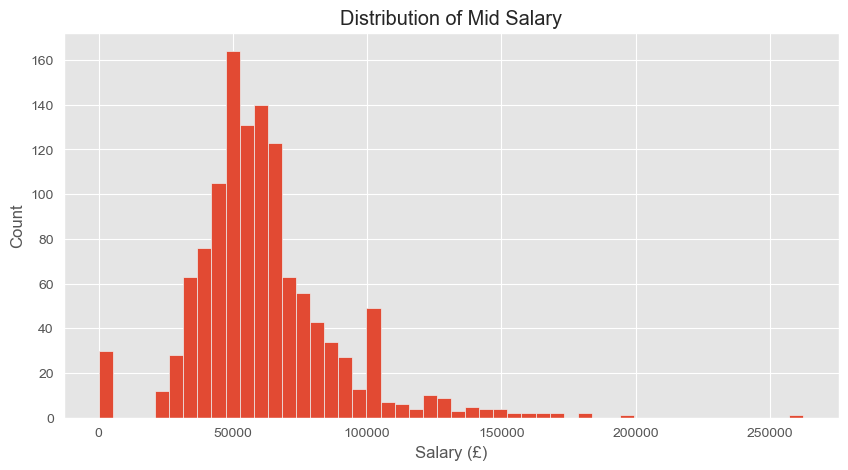

In [5668]:
import matplotlib.pyplot as plt
plt.style.use("ggplot")

df['salary_mid'] = (df['salary_min'] + df['salary_max']) / 2

df['salary_mid'].hist(bins=50, figsize=(10,5))
plt.title('Distribution of Mid Salary')
plt.xlabel('Salary (£)')
plt.ylabel('Count')
plt.show()

#### High Salary Outliers (>£150k)

19 roles exceed £150k mid salary. These appear legitimate — SC cleared roles, 
senior/principal positions, top-tier tech companies (Waymo), and likely 
annualised contract day rates. All have salary_is_predicted = False confirming 
employer-stated figures. These will be retained in the dataset.

In [5669]:
df[df['salary_mid'] > 150000][['title', 'company', 'salary_min', 'salary_max', 'salary_is_predicted']]

,title,company,salary_min,salary_max,salary_is_predicted
184,Senior Data Scientist,Clarity Innovations,97000.0,233000.0,False
238,Staff Data Scientist,Iterative Health,200000.0,325000.0,False
661,Data Engineer,Morson Edge,156000.0,169000.0,False
805,Machine Learning Engineer,Almedia,130000.0,230000.0,False
843,Staff Machine Learning Engineer,Hexwired Recruitment Limited,160000.0,200000.0,False
908,Senior Machine Learning Engineer,Epic Games,135000.0,175000.0,False
939,"Staff Machine Learning Engineer, Simulation",Waymo,155000.0,163000.0,False
961,"Principal Machine Learning Engineer, Foundatio...",Cambridge Mobile Telematics,177000.0,221300.0,False
968,"Manager, Machine Learning Engineering (Repayme...",Affirm,142000.0,190000.0,False
998,"Staff / Principal Machine Learning Engineer, S...",Inworld,140000.0,200000.0,False


#### Low Salary Outliers (<£20k)

30 rows has a salary_mid of £450 which clearly appears to be a daily contract rate misreported 
as an annual figure. Dropped from the dataset.

In [5670]:
df[df['salary_mid'] < 20000][['title', 'company', 'salary_min', 'salary_max', 'contract_type']]

,title,company,salary_min,salary_max,contract_type
38,Data Scientist,Harnham - Data & Analytics Recruitment,500.0,650.0,contract
142,Senior Data Scientist,Warden AI,100.0,120.0,None
199,Senior Data Scientist,Sirius Analysis Limited,25.0,25.0,None
200,Senior Data Scientist,Sirius Analysis Limited,25.0,25.0,permanent
209,Senior Data Scientist,National Energy System Operator,240.0,6000.0,None
228,Data Scientist (IT),LA International Computer Consultants Ltd,465.0,465.0,contract
315,Data Analyst,red recruitment,15.0,15.0,contract
317,Data Analyst,Reed,18.0,23.0,contract
325,Data Analyst,Proactive Appointments,400.0,475.0,contract
327,Data Analyst,Harnham - Data & Analytics Recruitment,350.0,400.0,contract


In [5671]:
df = df[df['salary_mid'] >= 20000]
print(df.shape)

(1191, 16)


Only 2 jobs are listed without a company name. These will be removed for a cleaner dataset.

In [5672]:
df[df['company'].isnull()][['title', 'company', 'salary_min', 'salary_max', 'contract_type']]

,title,company,salary_min,salary_max,contract_type
319,Data Analyst,None,35663.88,35663.88,contract
400,Data Analyst,None,40763.00,40763.00,None


In [5673]:
df = df[df['company'].notna()]
print(df.shape)

(1189, 16)


## Salary Distribution by Role

Data Analysts command the lowest median salary (~£48k) with the tightest 
distribution, reflecting the more standardised nature of the role. Data Scientists 
and ML Engineers show the highest medians (~£65k) with wider spreads along (though data engineers are the widest), consistent with greater seniority variation. All roles show high-end outliers likely 
representing senior, principal, or contract positions. Data Scientist and ML Engineer are jobs that seem to have a great deal of specialisation due to outlier job listings reaching a maximum of 200K and 250K+ respectively.

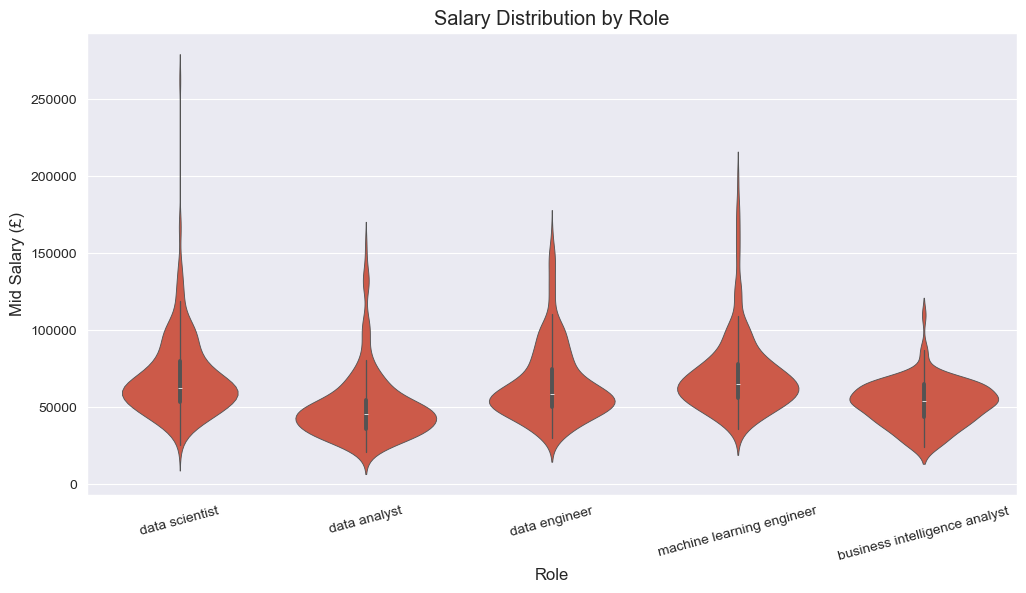

In [5674]:
import seaborn as sns
sns.set_style("darkgrid")
# print(df["title"].unique()[:5], len(df["title"].unique()))
# print(df["category"].unique())
plt.figure(figsize=(12,6))
sns.violinplot(data=df, x='search_term', y='salary_mid')
plt.title('Salary Distribution by Role')
plt.xlabel('Role')
plt.ylabel('Mid Salary (£)')
plt.xticks(rotation=15)
plt.show()

In [5675]:
df["location"].value_counts().head(20)

location
London, UK                             344
UK                                     125
Manchester, Greater Manchester          37
Belfast, Northern Ireland               28
Farringdon, Central London              27
The City, Central London                23
Leeds, West Yorkshire                   18
Newcastle Upon Tyne, Tyne & Wear        17
Bristol, South West England             17
Charing Cross, Central London           15
Birmingham, West Midlands               14
Glasgow, Scotland                       14
Manchester Science Park, Manchester     13
South West London, London               12
Cheltenham, Gloucestershire             11
Edinburgh, Scotland                     10
Sheffield, South Yorkshire               8
Liverpool, Merseyside                    8
Holbeck, Leeds                           7
Gloucester, Gloucestershire              7
Name: count, dtype: int64

In [5676]:
df[~df['location'].str.lower().str.contains('london|manchester|birmingham|' \
        'leeds|bristol|edinburgh|glasgow|scotland|belfast|northern ireland|newcastle'
        '|sheffield|liverpool', na=False)]['location'].value_counts()

location
UK                                125
Cheltenham, Gloucestershire        11
Gloucester, Gloucestershire         7
Cambridge, Cambridgeshire           6
Milton Keynes, Buckinghamshire      5
                                 ... 
Old Catton, Norwich                 1
Cambus, Alloa                       1
Larbert, Falkirk County             1
Little Laver, Ongar                 1
Caversham, Reading                  1
Name: count, Length: 189, dtype: int64

In [5677]:
def simplify_location(loc):
    loc = loc.lower()
    if 'london' in loc:
        return 'London'
    elif 'manchester' in loc:
        return 'Manchester'
    elif 'birmingham' in loc:
        return 'Birmingham'
    elif 'leeds' in loc:
        return 'Leeds'
    elif 'bristol' in loc:
        return 'Bristol'
    elif 'edinburgh' in loc or 'glasgow' in loc or 'scotland' in loc:
        return 'Scotland'
    elif 'belfast' in loc or 'northern ireland' in loc:
        return 'Northern Ireland'
    elif 'newcastle' in loc:
        return 'Newcastle'
    elif 'sheffield' in loc:
        return 'Sheffield'
    elif 'liverpool' in loc:
        return 'Liverpool'
    elif 'cheltenham' in loc or 'gloucester' in loc:
        return 'Gloucestershire'
    elif 'cambridge' in loc:
        return 'Cambridge'
    elif 'milton keynes' in loc:
        return 'Milton Keynes'
    else:
        return 'Other'

df['location_simplified'] = df['location'].apply(simplify_location)
df['location_simplified'].value_counts()

location_simplified
London              513
Other               382
Manchester           64
Northern Ireland     40
Scotland             32
Leeds                29
Bristol              25
Birmingham           23
Newcastle            22
Gloucestershire      20
Sheffield            13
Liverpool            10
Cambridge             9
Milton Keynes         7
Name: count, dtype: int64

#### Salary Distribution by Location -- CHECK AGAIN

London shows a consistently high median salary (~£63k) with a wide spread 
reflecting diverse seniority levels. Scotland and Northern Ireland show 
high variance likely due to small sample sizes and sector-specific roles 
(defence, fintech). Northern English cities (Birmingham, Sheffield, Newcastle) 
cluster at the lower end, consistent with UK regional salary patterns.
Note: The 'Other' category contains smaller cities 
with insufficient data for individual categories.

In [5678]:
df.groupby('location_simplified')['salary_mid'].median().sort_values(ascending=False)

location_simplified
Scotland            65000.000
London              62826.180
Gloucestershire     60557.875
Bristol             60000.000
Northern Ireland    60000.000
Cambridge           59084.330
Manchester          57662.475
Milton Keynes       56550.000
Leeds               55041.570
Other               52000.000
Liverpool           51510.100
Newcastle           51368.750
Sheffield           50000.000
Birmingham          47777.230
Name: salary_mid, dtype: float64

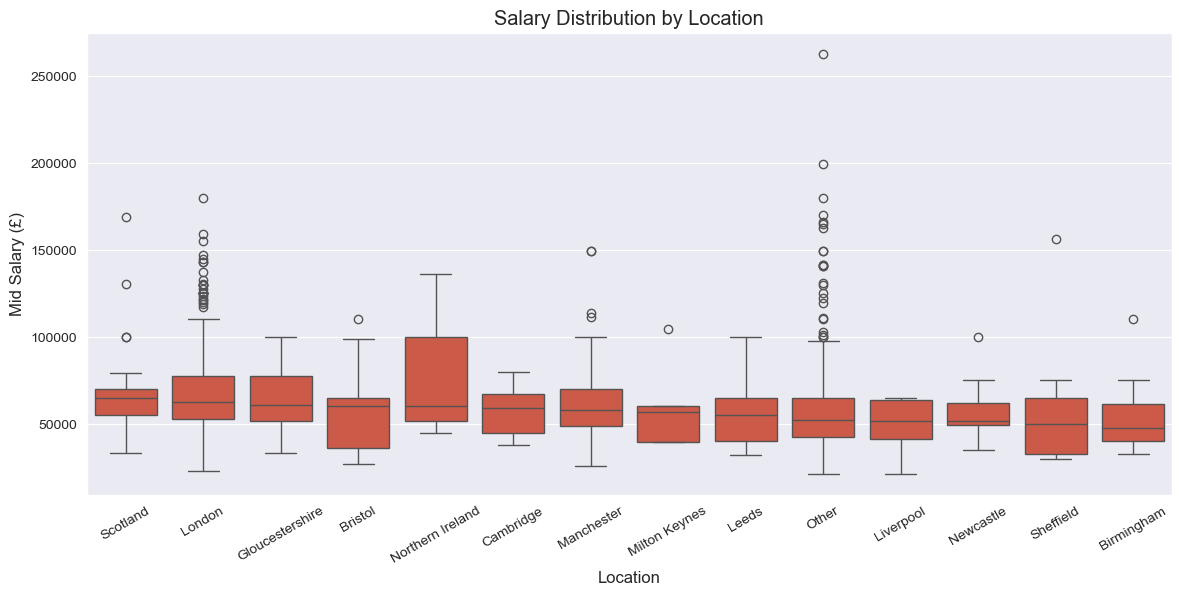

In [5679]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='location_simplified', y='salary_mid', 
            order=df.groupby('location_simplified')['salary_mid'].median().sort_values(ascending=False).index)
plt.title('Salary Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Mid Salary (£)')
plt.xticks(rotation=30)
plt.show()

#### Most In-Demand Technical Skills

SQL and Python dominate across all roles, appearing in 73 and 51 postings 
respectively. Power BI's high ranking reflects strong BI analyst demand. Additionally, 
Azure outranks AWS suggesting UK enterprise preference for Microsoft tooling. 
PyTorch leads TensorFlow consistent with current industry adoption trends.
Git and Scala dropped significantly after applying word boundary matching, 
confirming earlier counts were inflated by partial string matches.

#### Soft Skills Analysis

'Analytical' appears in around 68 postings but likely reflects boilerplate language 
rather than a specific requirement. Leadership appears more than expected, 
consistent with the seniority skew in the dataset. Stakeholder management, 
collaboration and communication form the core soft skill expectations across 
DS/ML roles.

           skill  count
0            sql     73
1         python     51
2       power bi     33
3          azure     28
4              r     27
5            aws     23
6        tableau     12
7          excel     12
8        airflow      9
9          spark      9
10           gcp      9
11           dbt      9
12       pytorch      8
13        looker      6
14         kafka      6
15    tensorflow      6
16          java      4
17  scikit-learn      4
18        docker      3
19    kubernetes      3
                  skill  count
0            analytical     68
1            leadership     19
2         collaboration     14
3           stakeholder     10
4         communication     10
5                 agile      9
6            initiative      5
7       problem solving      2
8              teamwork      2
9   attention to detail      1
10         self-starter      1


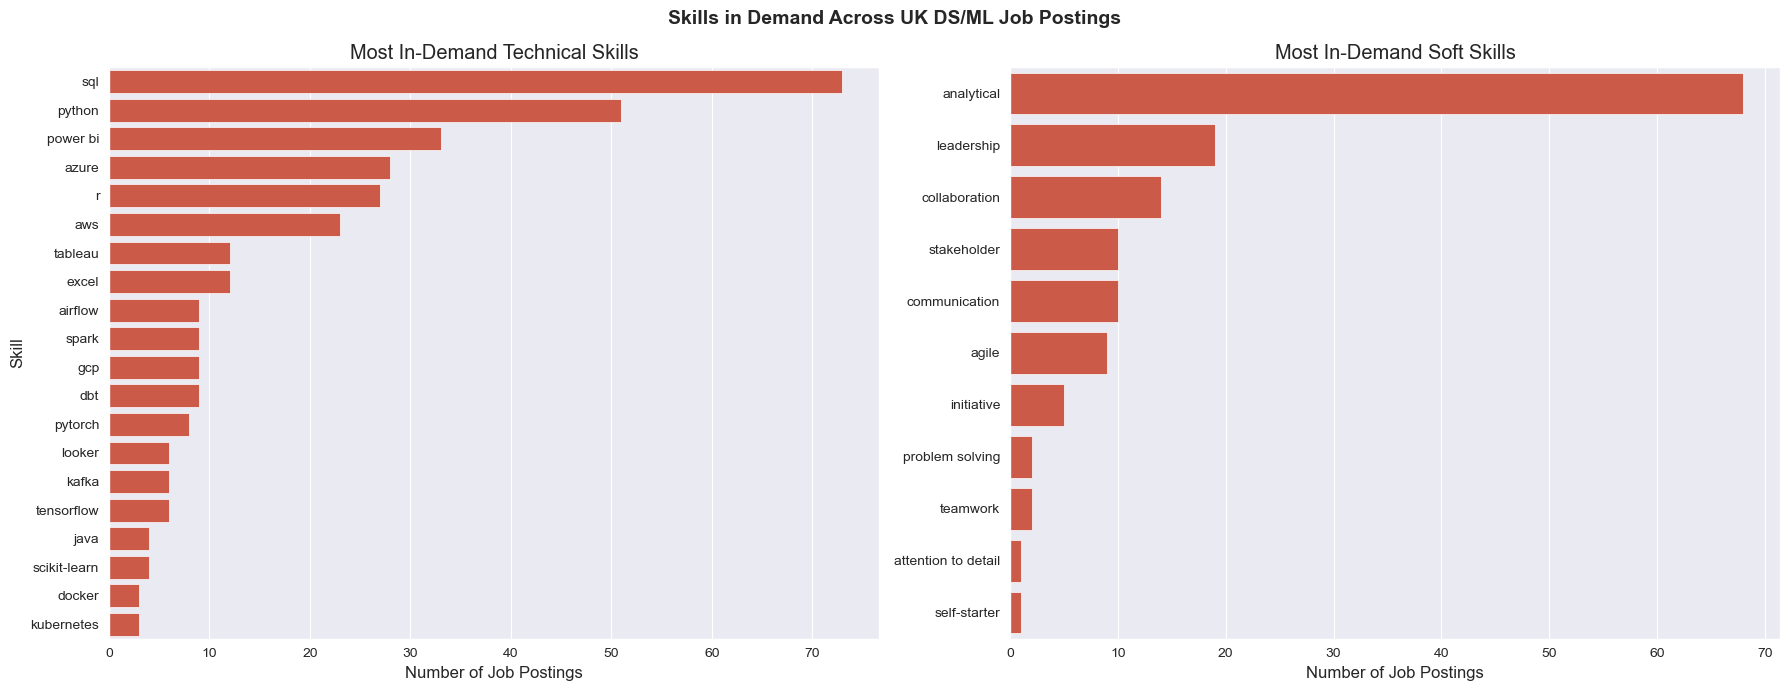

In [5680]:
import re
from collections import Counter


skills = [
    # General
    'python', 'sql', 'r', 'scala', 'java', 'git', 'linux', 'excel',
    # Data Science
    'pandas', 'numpy', 'scikit-learn', 'xgboost', 'matplotlib', 'seaborn', 'jupyter', 'statsmodels',
    # ML/DL
    'pytorch', 'tensorflow', 'keras', 'mlflow', 'hugging face', 'fastapi',
    # Data Engineering
    'spark', 'hadoop', 'kafka', 'airflow', 'docker', 'kubernetes', 'dbt',
    # Cloud
    'aws', 'gcp', 'azure',
    # BI
    'power bi', 'tableau', 'looker', 'dax', 'qlik',
]

soft_skills = [
    'communication', 'stakeholder', 'collaboration', 'teamwork',
    'problem solving', 'critical thinking', 'presentation',
    'leadership', 'agile', 'scrum', 'project management',
    'analytical', 'attention to detail', 'self-starter', 'initiative'
]

df["description"] = df["description"].str.lower()

def extract_skills(description, skill_list):
    found = []
    for skill in skill_list:
        # Use word boundary matching for single words
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, description):
            found.append(skill)
    return found

df["skills_found"] = df["description"].apply(lambda x: extract_skills(x, skills))
df["soft_skills_found"] = df["description"].apply(lambda x: extract_skills(x, soft_skills))

# Count both
all_hard = [skill for sublist in df["skills_found"] for skill in sublist]
all_soft = [skill for sublist in df["soft_skills_found"] for skill in sublist]

hard_df = pd.DataFrame(Counter(all_hard).most_common(20), columns=["skill", "count"])
soft_df = pd.DataFrame(Counter(all_soft).most_common(15), columns=["skill", "count"])

print(hard_df)
print(soft_df)

# Side by side figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=hard_df, x='count', y='skill', ax=axes[0])
axes[0].set_title('Most In-Demand Technical Skills')
axes[0].set_xlabel('Number of Job Postings')
axes[0].set_ylabel('Skill')

sns.barplot(data=soft_df, x='count', y='skill', ax=axes[1])
axes[1].set_title('Most In-Demand Soft Skills')
axes[1].set_xlabel('Number of Job Postings')
axes[1].set_ylabel('')

plt.suptitle('Skills in Demand Across UK DS/ML Job Postings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#### Seniority Analysis

There is a clear salary progression across seniority levels: Junior (~£40k) -> Mid (~£57k) 
-> Senior (~£65k) -> Lead (~£80k), validating the seniority extraction logic. 
Mid-level dominates at 830 postings since the majority of postings don't state 
seniority in the title. However, Junior roles are scarce (25 postings), consistent 
with the current UK DS/ML market favouring experienced hires.

In [5681]:
def extract_seniority(title):
    title = title.lower()
    if any(word in title for word in ['head', 'director', 'vp', 'vice president', 'principal', 'lead']):
        return 'Lead'
    elif any(word in title for word in ['senior', 'sr.', 'sr ']):
        return 'Senior'
    elif any(word in title for word in ['junior', 'jr.', 'jr ', 'graduate', 'intern', 'entry']):
        return 'Junior'
    else:
        return 'Mid'

df['seniority'] = df['title'].apply(extract_seniority)
df['seniority'].value_counts()

seniority
Mid       835
Senior    211
Lead      115
Junior     28
Name: count, dtype: int64

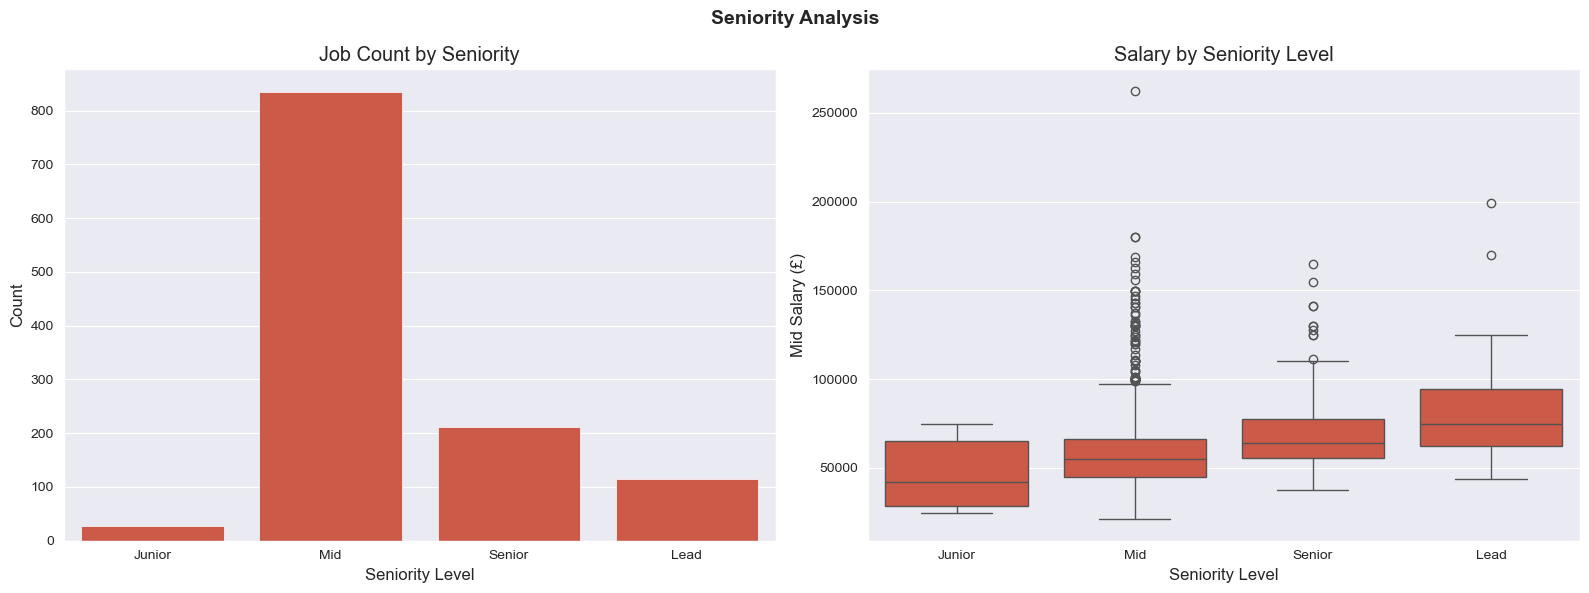

In [5682]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count by seniority
sns.countplot(data=df, x='seniority', 
              order=['Junior', 'Mid', 'Senior', 'Lead'], 
              ax=axes[0])
axes[0].set_title('Job Count by Seniority')
axes[0].set_xlabel('Seniority Level')
axes[0].set_ylabel('Count')

# Salary by seniority
sns.boxplot(data=df, x='seniority', y='salary_mid',
            order=['Junior', 'Mid', 'Senior', 'Lead'],
            ax=axes[1])
axes[1].set_title('Salary by Seniority Level')
axes[1].set_xlabel('Seniority Level')
axes[1].set_ylabel('Mid Salary (£)')

plt.suptitle('Seniority Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5683]:
df.head(15)

,id,adzuna_id,title,company,location,category,salary_min,salary_max,salary_is_predicted,contract_time,contract_type,description,created,fetched_at,search_term,salary_mid,location_simplified,skills_found,soft_skills_found,seniority
0,2610,5852097024,Data Scientist,Hackajob Ltd,"Frimley, Camberley",IT Jobs,90000.00,90000.00,False,None,permanent,hackajob is partnering directly with bae syste...,2026-08-22 06:38:34,2026-09-01 07:27:05.292482,data scientist,90000.00,Other,[],[],Mid
1,2611,5861182268,Data Scientist,Ntt Data,"London, UK",IT Jobs,61153.77,61153.77,True,full_time,None,we are looking for a data scientist with at le...,2026-08-29 16:29:26,2026-09-01 07:27:05.292482,data scientist,61153.77,London,"[python, r]",[],Mid
2,2612,5825674473,Data Scientist / Senior Data Scientist,C3 AI,"London, UK",IT Jobs,59484.39,59484.39,True,full_time,None,"as a member of the c3 ai data science team, yo...",2026-08-02 14:00:14,2026-09-01 07:27:05.292482,data scientist,59484.39,London,[],[],Senior
3,2613,5818233809,Lead Data Scientist,Hackajob Ltd,"Holbeck, Leeds",IT Jobs,100000.00,100000.00,False,None,permanent,hackajob is partnering directly with jet2.com ...,2026-07-28 12:08:12,2026-09-01 07:27:05.292482,data scientist,100000.00,Leeds,[],[],Lead
4,2614,5856135789,Senior Data Scientist,TALENT INTERNATIONAL UK LTD,UK,IT Jobs,130000.00,152100.00,False,None,contract,job description: role: senior data scientist r...,2026-08-26 02:45:40,2026-09-01 07:27:05.292482,data scientist,141050.00,Other,[],[],Senior
5,2615,5861079746,Data Science Manager,Hackajob Ltd,"Charing Cross, Central London",Consultancy Jobs,100000.00,100000.00,False,None,permanent,hackajob is partnering directly with accenture...,2026-08-29 14:49:38,2026-09-01 07:27:05.292482,data scientist,100000.00,London,[],[leadership],Mid
6,2616,5858065627,Data Scientist Manager,Hackajob Ltd,"Charing Cross, Central London",IT Jobs,90000.00,90000.00,False,None,permanent,hackajob is partnering directly with kainos to...,2026-08-27 10:48:07,2026-09-01 07:27:05.292482,data scientist,90000.00,London,[],[],Mid
7,2617,5855394777,Data Scientist,INNOVIZ LIMITED,"Milton Keynes, Buckinghamshire",IT Jobs,34000.00,45000.00,False,full_time,permanent,we are seeking a highly skilled and experience...,2026-08-25 15:41:39,2026-09-01 07:27:05.292482,data scientist,39500.00,Milton Keynes,[],[],Mid
8,2618,5862426589,Data Science Team Leader,Hackajob Ltd,"Charing Cross, Central London",IT Jobs,100000.00,100000.00,False,None,permanent,hackajob is partnering directly with just eat ...,2026-08-30 22:50:49,2026-09-01 07:27:05.292482,data scientist,100000.00,London,[],[],Lead
9,2619,5858064903,"Director, Data Scientist Management",Hackajob Ltd,"Charing Cross, Central London",IT Jobs,100000.00,100000.00,False,None,permanent,hackajob is partnering directly with bny mello...,2026-08-27 10:47:33,2026-09-01 07:27:05.292482,data scientist,100000.00,London,[],[],Lead


In [5684]:
# df['category'].nunique()
df['company'].value_counts()[df['company'].value_counts() > 5]

company
Hackajob Ltd                              52
DWP Digital                               24
IT Online Learning                        23
Faculty AI                                22
Harnham - Data & Analytics Recruitment    19
Capital One UK                            19
A&O Shearman                              18
Anson McCade                              18
Spotify                                   17
Wise                                      17
Ad Warrior Ltd                            14
NEWTO TRAINING LIMITED                    10
Tenth Revolution Group                    10
Ocho                                      10
Informed Solutions                         8
Jacobs                                     8
Bauhaus Consultants                        8
Hexwired Recruitment Limited               7
ASOS                                       7
Wayve                                      6
Deliveroo                                  6
AECOM                                      6
G-

In [5685]:
# Keep top N companies, group rest as 'Other'
top_companies = df['company'].value_counts()[df['company'].value_counts() > 5].index
df['company_grouped'] = df['company'].apply(lambda x: x if x in top_companies else 'Other')
len(df[df['company_grouped'] != "Other"])

365

## Feature Engineering

### Categorical Encoding
Categorical features (search term, location, seniority, contract type and time) 
are encoded using LabelEncoder, converting string categories into integer 
representations suitable for tree-based models. Contract time and type nulls 
are filled with 'unknown' before encoding rather than dropping rows, preserving 
the ~50% of postings that don't specify these fields.

Company was considered as a feature but excluded from this version — high 
cardinality (700+ unique values) with most companies appearing only once 
makes it unlikely to generalise well. Retained as a potential improvement 
for future iterations.

### Skill Features
Skills extracted during EDA are converted into binary columns using 
pd.get_dummies() on the exploded skills list — one column per skill, 
1 if the skill appeared in the job description, 0 otherwise. This allows 
the model to learn the independent salary contribution of each skill.

In [5686]:
from sklearn.preprocessing import LabelEncoder

#Encode Categoricals
le = LabelEncoder()
df["search_term_enc"] = le.fit_transform(df["search_term"])
df["location_simplified_enc"] = le.fit_transform(df["location_simplified"])
df["seniority_enc"] = le.fit_transform(df["seniority"])

df["contract_time"] = df["contract_time"].fillna("unknown")
df["contract_type"] = df["contract_type"].fillna("unknown")

df["contract_time_enc"] = le.fit_transform(df['contract_time'])
df["contract_type_enc"] = le.fit_transform(df['contract_type'])

df['salary_is_predicted'] = df['salary_is_predicted'].astype(int)

# df["company_grouped_enc"] = le.fit_transform(df["company_grouped"]) #-- feature not used currently

skills_dummies = df['skills_found'].explode().str.get_dummies().groupby(level=0).max() #Getting One hot encoding form of skills_found
df = pd.concat([df, skills_dummies], axis=1)

### Feature Matrix
The final feature matrix X consists of 5 encoded categorical features 
plus one binary column per skill. The target y is salary_mid — the 
midpoint of the advertised salary range, used as a continuous regression target.

In [5687]:
feature_cols = ["search_term_enc", "location_simplified_enc", "seniority_enc", "contract_time_enc", "contract_type_enc", 'salary_is_predicted'] + list(skills_dummies.columns)

X = df[feature_cols]
y = df['salary_mid']

print(X.shape)

(1189, 37)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_selection import SelectKBest, f_regression
import spacy

nlp = spacy.load('en_core_web_sm')

df['description_lemmatised'] = [
    ' '.join([token.lemma_ for token in doc if not token.is_punct])
    for doc in nlp.pipe(df['description'], batch_size=50)
]

custom_stops = list(TfidfVectorizer(stop_words='english').get_stop_words()) + skills

tfidf = TfidfVectorizer(max_features=100, stop_words=custom_stops,
                         max_df=0.7, #ignore words appearing in >70% of documents
                         )
tfidf_features = tfidf.fit_transform(df["description_lemmatised"])

# 2. Select best features by salary correlation
selector = SelectKBest(f_regression, k=50)
tfidf_selected = selector.fit_transform(tfidf_features, y)

# # Getting tf idf feature names 
tfidf_fnames_all = tfidf.get_feature_names_out()
tfidf_fnames_selected = tfidf_fnames_all[selector.get_support()]
print(tfidf_fnames_selected)
all_feature_names = feature_cols + tfidf_fnames_selected.tolist()

X_sparse = csr_matrix(X.values)
X_combined = hstack([X_sparse, tfidf_selected])

KeyboardInterrupt: 

### Model Training

Data is split 80/20 into training and test sets. Quantile-based salary bands 
are computed for optional stratified splitting, ensuring each salary range is 
proportionally represented across both sets.

In [5694]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb

salary_bands = pd.qcut(y, q=5, labels=False)  # 5 quantile-based bands
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42) #, stratify=salary_bands



### XGBoost Regressor

XGBoost (Extreme Gradient Boosting) builds trees sequentially, each correcting 
the errors of the previous one. Key hyperparameters:
- `n_estimators=1000` — number of sequential trees
- `learning_rate=0.01` — conservative step size, each tree contributes little individually
- `max_depth=8` — maximum tree depth, controls complexity
- `subsample=0.8` — each tree trains on 80% of rows, reducing overfitting
- `colsample_bytree=0.8` — each tree uses 80% of features, forcing diversity
- `min_child_weight=3` — minimum samples in a leaf, acts as regularisation

In [5699]:
model_tuned = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_tuned.fit(X_train, y_train)
y_pred_tuned = model_tuned.predict(X_test)

print(f"MAE: £{mean_absolute_error(y_test, y_pred_tuned):,.0f}")
print(f"R² Score: {r2_score(y_test, y_pred_tuned):.3f}")

MAE: £11,768
R² Score: 0.542


### Feature Importance Analysis

Top predictors:
- `salary_is_predicted` (0.080) — whether Adzuna estimated or the employer 
  stated the salary remains the strongest single signal, reflecting two 
  distinct salary distributions in the data. Its reduced dominance compared 
  to earlier model iterations (previously 0.21) suggests TF-IDF features 
  are distributing importance more broadly.

- `search_term_enc` (0.049) — role type is the second strongest engineered 
  feature, consistent with the clear salary differences across roles observed 
  in EDA.

- **TF-IDF terms dominate the mid-rankings** — `key`, `contract`, `airflow`, 
  `build`, `engineering`, `partner`, `environment` all appear ahead of most 
  engineered features. This confirms lemmatization improved TF-IDF signal 
  quality, though some boilerplate terms (`key`, `opportunity`, `join`, `play`, 
  `world`) persist suggesting further stopword refinement could help.

- `contract_type_enc` (0.017), `seniority_enc` (0.015), 
  `location_simplified_enc` (0.014) — engineered categoricals contribute 
  meaningfully but rank lower than expected given their clear salary signal 
  in EDA. This is likely due to high cardinality within categories 
  (e.g. 830 rows labelled Mid) reducing discriminative power.

- Technical skills (`python`, `aws`, `spark`, `ml`) appear in the lower 
  rankings — individually modest but collectively significant across the 
  full feature set.

- `datum` appearing as a feature is a lemmatization artefact — spaCy 
  incorrectly lemmatizes "data" to "datum" in some contexts. Worth noting 
  as a data quality observation.

In [5700]:
feat_importance = pd.Series(model_tuned.feature_importances_, index=all_feature_names).sort_values(ascending=False)
print(feat_importance.head(55))

salary_is_predicted        0.079950
search_term_enc            0.049396
key                        0.039110
contract                   0.034205
airflow                    0.032011
start                      0.029496
build                      0.026018
experienced                0.023363
engineering                0.021746
partner                    0.021604
environment                0.021425
opportunity                0.020993
analyst                    0.019291
scientist                  0.018511
performance                0.017876
technology                 0.016885
contract_type_enc          0.016767
lead                       0.016622
intelligence               0.016101
global                     0.015800
seniority_enc              0.015359
hire                       0.015299
focus                      0.015126
contract_time_enc          0.014526
pipeline                   0.014396
base                       0.014040
world                      0.014015
london                     0

In [5701]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42) #Splitting & Shuffling Data before cross validation
cv_scores = cross_val_score(model_tuned, X_train, y_train, cv=kf, scoring='r2')
print(f"CV R² scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

CV R² scores: [0.51118349 0.49667968 0.4741411  0.45736921 0.45207572]
Mean R²: 0.478 (+/- 0.023)


In [5702]:
import joblib
joblib.dump(model_tuned, '../models/model.pkl')
joblib.dump(tfidf, '../models/tfidf.pkl')
joblib.dump(selector, '../models/selector.pkl')

FileNotFoundError: [Errno 2] No such file or directory: '../models/model.pkl'